# Ocular Disease Classification: End-to-End Pipeline
**Dataset:** `manan1717/ocular-disease-dataset` (Kaggle)  
**Classes:** AMD (A), Cataract (C), Diabetic Retinopathy (D), Glaucoma (G), Hypertensive Retinopathy (H), Myopia (M), Normal (N)

## Project Phases
* **Phase 1:** Exploratory Data Analysis (EDA)
* **Phase 2:** Image Preprocessing
* **Phase 3:** Feature Extraction (HOG, GLCM, LBP)
* **Phase 4:** Dimensionality Reduction (PCA)
* **Phase 5:** Machine Learning Models (SVM, Random Forest, XGBoost)
* **Phase 6:** Evaluation
---

In [ ]:
# --- Imports ---
import os
import cv2
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

try:
    import opendatasets as od
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'opendatasets'])
    import opendatasets as od

# Plotting aesthetics
plt.style.use('ggplot')
sns.set_palette('muted')
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# --- Download Dataset & Map Paths ---
DATASET_URL = 'https://www.kaggle.com/datasets/manan1717/ocular-disease-dataset'
DEST_DIR = './ocular_dataset'
IMG_EXTS = ('.jpg', '.jpeg', '.png', '.bmp')

FULL_NAMES = {
    'A': 'AMD', 'C': 'Cataract', 'D': 'Diabetic Retinopathy',
    'G': 'Glaucoma', 'H': 'Hypertensive Retinopathy',
    'M': 'Myopia', 'N': 'Normal'
}

# 1. Download from Kaggle
if not os.path.exists(DEST_DIR) or not os.listdir(DEST_DIR):
    print('Downloading dataset...')
    od.download(DATASET_URL, data_dir=DEST_DIR)
else:
    print('Dataset already exists — skipping download.')

# 2. Auto-discover Class Folders
class_folders = {}
for root, dirs, files in os.walk(DEST_DIR):
    imgs = [f for f in files if f.lower().endswith(IMG_EXTS)]
    if imgs:
        class_name = os.path.basename(root)
        class_folders[class_name] = root

if not class_folders:
    raise RuntimeError('No image folders found. Please check the dataset directory.')

print('\n--- Class Folders Found ---')
for cls, path in sorted(class_folders.items()):
    print(f"[{cls}] {FULL_NAMES.get(cls, cls)}: {path}")

Dataset already exists — skipping download.

--- Class Folders Found ---
[A] AMD: ./ocular_dataset/ocular-disease-dataset/preprocessed/A
[C] Cataract: ./ocular_dataset/ocular-disease-dataset/preprocessed/C
[D] Diabetic Retinopathy: ./ocular_dataset/ocular-disease-dataset/preprocessed/D
[G] Glaucoma: ./ocular_dataset/ocular-disease-dataset/preprocessed/G
[H] Hypertensive Retinopathy: ./ocular_dataset/ocular-disease-dataset/preprocessed/H
[M] Myopia: ./ocular_dataset/ocular-disease-dataset/preprocessed/M
[N] Normal: ./ocular_dataset/ocular-disease-dataset/preprocessed/N


In [ ]:
DEST_DIR = './ocular_dataset'
IMG_EXTS = ('.jpg', '.jpeg', '.png', '.bmp')

class_folders = {}
for root, dirs, files in os.walk(DEST_DIR):
    imgs = [f for f in files if f.lower().endswith(IMG_EXTS)]
    if imgs:
        class_name = os.path.basename(root)
        class_folders[class_name] = root

if not class_folders:
    raise RuntimeError('No image folders found. Re-run Step 0.')

print('Found class folders:')
for cls, path in sorted(class_folders.items()):
    n = len([f for f in os.listdir(path) if f.lower().endswith(IMG_EXTS)])
    print(f'  {cls:<20} {n:>5} images')


Found class folders:
  A                      511 images
  C                     1008 images
  D                     3128 images
  G                     1646 images
  H                      420 images
  M                      739 images
  N                     2997 images


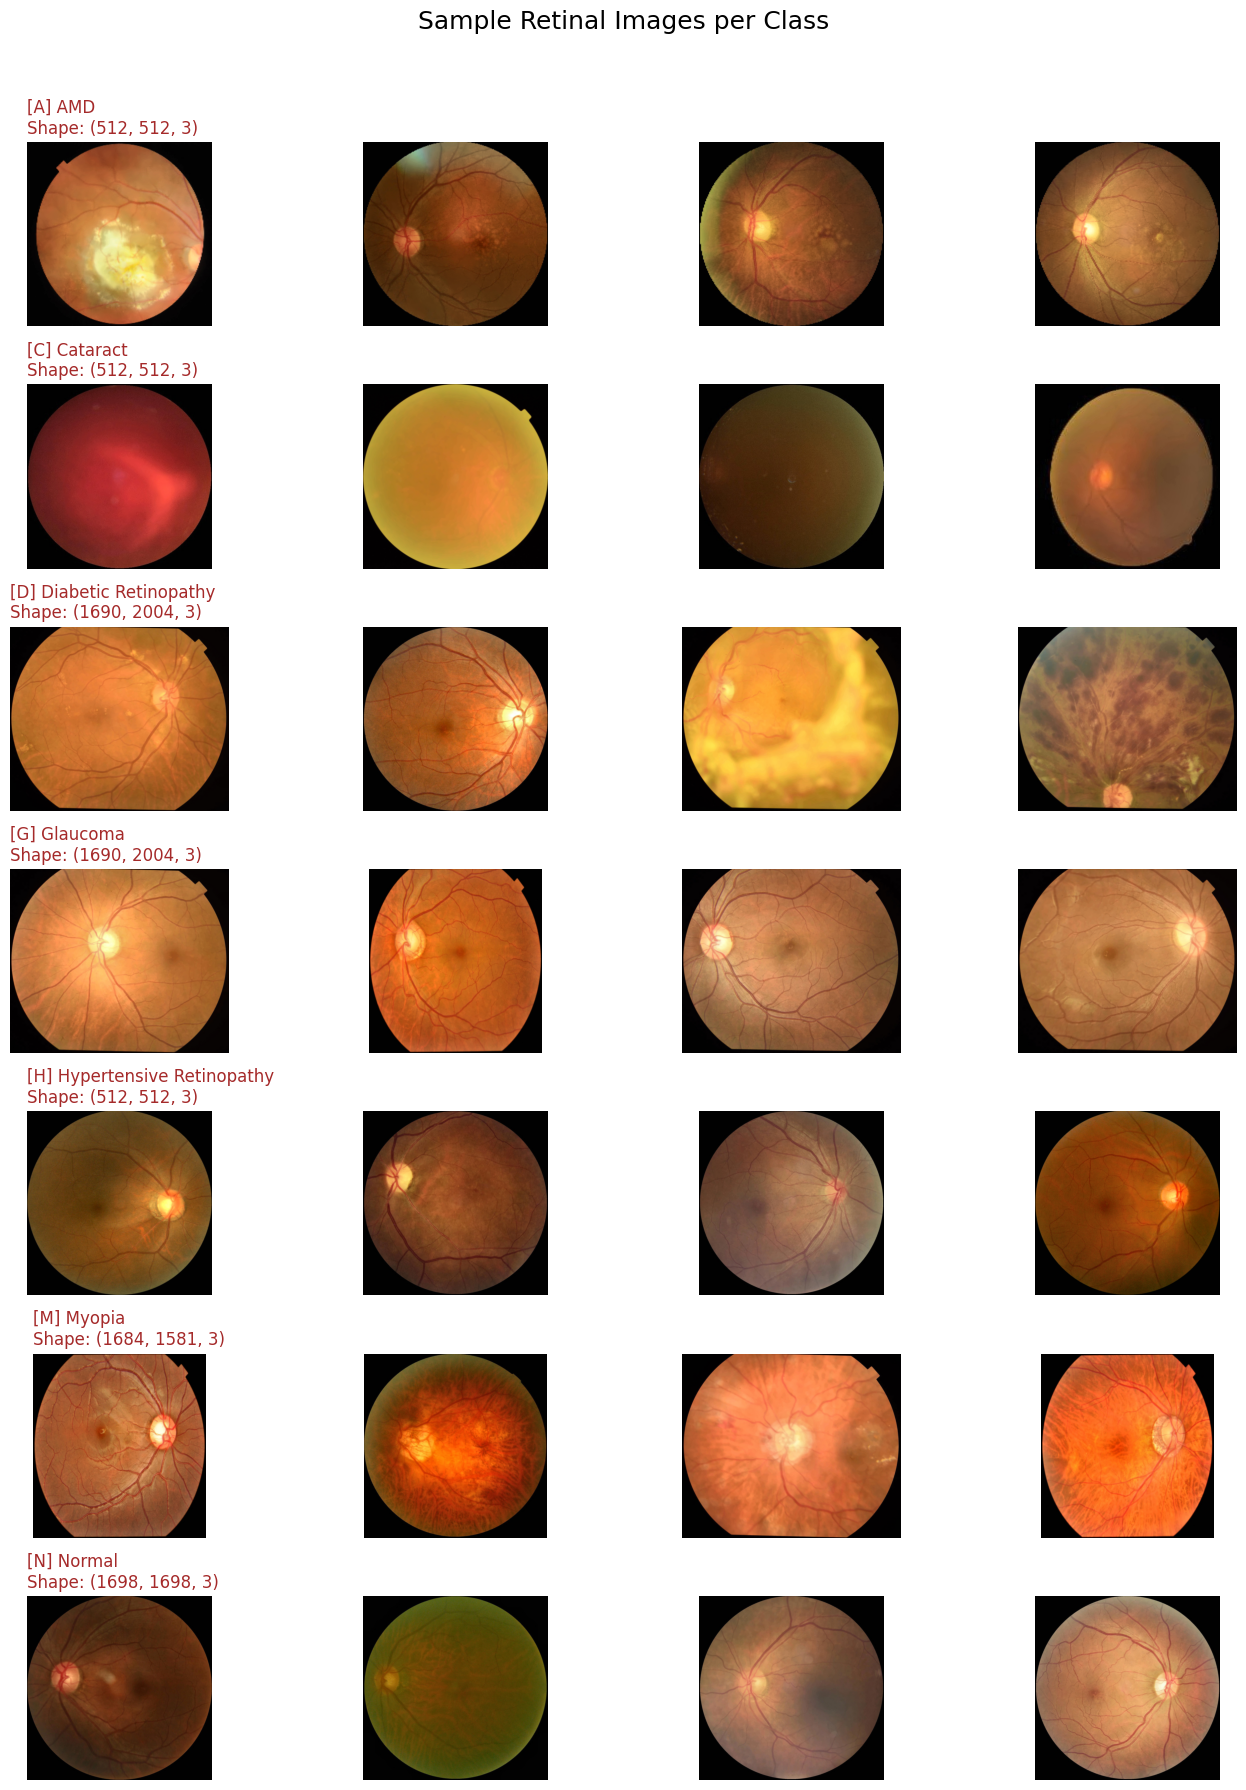

In [ ]:
# ---  Phase 1 (EDA) - Sample Image Grid ---
import random

# Set up a grid: 1 row per class, 4 columns (images) per row
num_classes = len(class_folders)
fig, axes = plt.subplots(nrows=num_classes, ncols=4, figsize=(14, 2.5 * num_classes))
fig.suptitle('Sample Retinal Images per Class', fontsize=18, y=1.02)

for i, (cls_name, folder) in enumerate(sorted(class_folders.items())):
    # Get all images in the folder
    images = [f for f in os.listdir(folder) if f.lower().endswith(IMG_EXTS)]

    # Select 4 random images
    sampled_imgs = random.sample(images, min(4, len(images)))

    for j, img_name in enumerate(sampled_imgs):
        img_path = os.path.join(folder, img_name)

        # Read image using OpenCV (loads in BGR format)
        img_bgr = cv2.imread(img_path)
        # Convert to RGB for proper Matplotlib rendering
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        axes[i, j].imshow(img_rgb)
        axes[i, j].axis('off')

        # Add labels to the first column
        if j == 0:
            full_name = FULL_NAMES.get(cls_name, cls_name)
            axes[i, j].set_title(f"[{cls_name}] {full_name}\nShape: {img_rgb.shape}",
                                 fontsize=12, loc='left', color='brown')

plt.tight_layout()
plt.show()

Checking image dimensions (sampling up to 200 images per class for speed)...


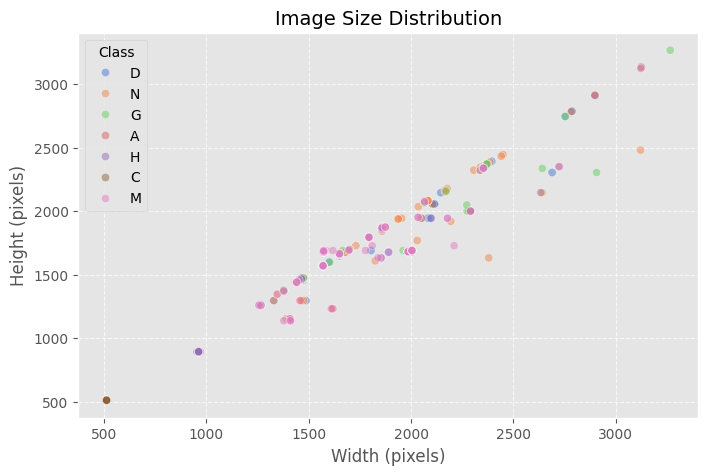


Unique Image Dimensions in Sample:
 Width  Height  Count
   512     512    553
   954     894      1
   961     894      1
   962     893      4
   962     894     10
   969     894      1
  1257    1256      1
  1257    1257      1
  1257    1260      1
  1257    1265      1
  1266    1254      1
  1266    1257     10
  1266    1265      1
  1329    1296      2
  1346    1346      2
  1376    1378      1
  1377    1377      6
  1378    1137      1
  1378    1369      1
  1378    1378      3
  1389    1152      1
  1403    1152      1
  1405    1152      1
  1407    1152      1
  1409    1152      7
  1410    1137      2
  1410    1152      6
  1435    1441      1
  1440    1441      1
  1441    1439      2
  1441    1440      1
  1441    1441     11
  1452    1458      1
  1456    1296      1
  1457    1458      1
  1458    1296      1
  1465    1296      1
  1465    1464      1
  1465    1474      1
  1468    1469      1
  1468    1474      1
  1469    1465      1
  1470    1296    

In [ ]:
# ---  Phase 1 (EDA) - Image Size Distribution ---
print("Checking image dimensions (sampling up to 200 images per class for speed)...")
sizes = []

for cls_name, folder in class_folders.items():
    images = [f for f in os.listdir(folder) if f.lower().endswith(IMG_EXTS)]
    # Sample up to 200 images per class to save memory/time
    sampled_imgs = random.sample(images, min(200, len(images)))

    for img_name in sampled_imgs:
        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path)
        if img is not None:
            h, w, c = img.shape
            sizes.append({'Class': cls_name, 'Width': w, 'Height': h})
        else:
            print(f"Warning: Could not read image {img_path} - might be corrupt!")

df_sizes = pd.DataFrame(sizes)

# Plotting the sizes
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_sizes, x='Width', y='Height', hue='Class', alpha=0.5)
plt.title('Image Size Distribution', fontsize=14)
plt.xlabel('Width (pixels)')
plt.ylabel('Height (pixels)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Print unique sizes
unique_sizes = df_sizes.groupby(['Width', 'Height']).size().reset_index(name='Count')
print("\nUnique Image Dimensions in Sample:")
print(unique_sizes.to_string(index=False))

if len(unique_sizes) == 1:
    print("\n  All images are already a uniform size.")
else:
    print("\n Images have varying sizes. We MUST resize them to a fixed dimension (e.g., 224x224) in Phase 2.")

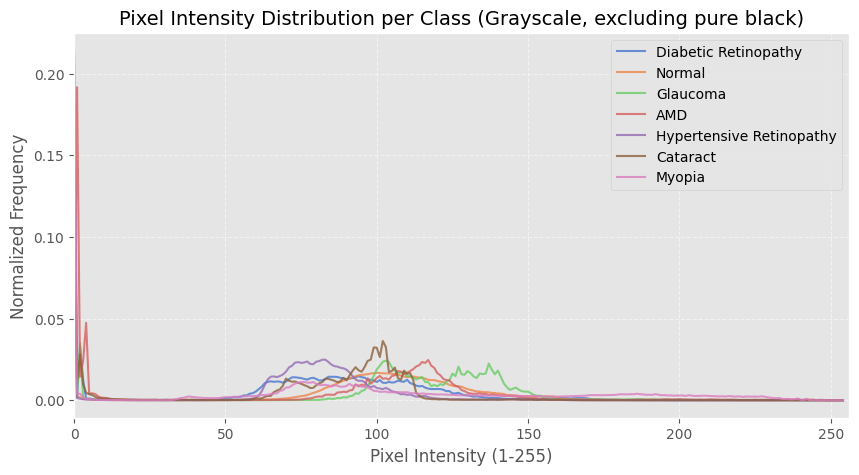

In [ ]:
# ---  Phase 1 (EDA) - Pixel Intensity Distribution ---
plt.figure(figsize=(10, 5))

for cls_name, folder in class_folders.items():
    images = [f for f in os.listdir(folder) if f.lower().endswith(IMG_EXTS)]
    if not images: continue

    # Pick 1 random image per class for the histogram
    sample_img_path = os.path.join(folder, random.choice(images))
    img = cv2.imread(sample_img_path, cv2.IMREAD_GRAYSCALE)

    # Calculate histogram (ignoring pure black background pixels = 0)
    hist = cv2.calcHist([img], [0], None, [255], [1, 256])

    # Normalize for comparison
    hist = hist / hist.sum()

    plt.plot(hist, label=FULL_NAMES.get(cls_name, cls_name), alpha=0.8)

plt.title('Pixel Intensity Distribution per Class (Grayscale, excluding pure black)', fontsize=14)
plt.xlabel('Pixel Intensity (1-255)')
plt.ylabel('Normalized Frequency')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim([0, 256])
plt.show()

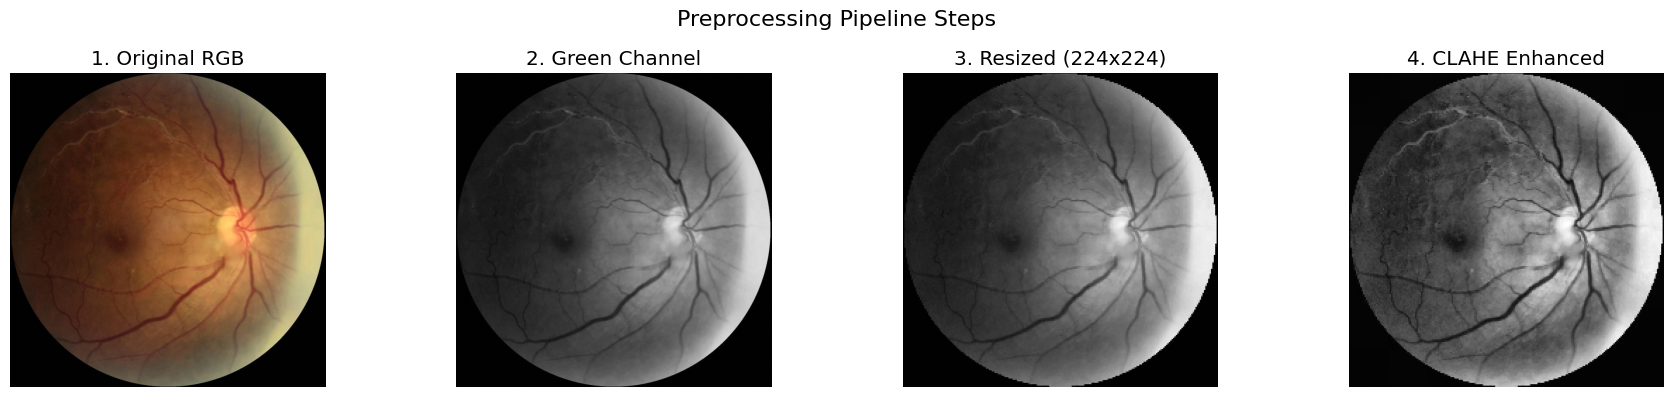

Final preprocessed array shape: (224, 224), Min val: 0.00392156862745098, Max val: 0.9725490196078431


In [ ]:
# ---  Phase 2 (Preprocessing) - Definition & Visualization ---
IMG_SIZE = 224

def preprocess_pipeline(img_path):
    """
    Reads an image and applies the preprocessing pipeline:
    Green Channel -> Resize -> CLAHE -> Normalize
    """
    # 1. Read image (BGR format)
    img = cv2.imread(img_path)
    if img is None:
        return None

    # 2. Extract Green Channel (Index 1 in BGR)
    # Retinal structures are best visible in the green spectrum
    green_channel = img[:, :, 1]

    # 3. Resize to fixed dimensions
    resized_img = cv2.resize(green_channel, (IMG_SIZE, IMG_SIZE))

    # 4. Apply CLAHE (Contrast Limited Adaptive Histogram Equalization)
    # This enhances local contrast and brings out blood vessels/lesions
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced_img = clahe.apply(resized_img)

    # 5. Normalize to [0, 1] for Machine Learning
    normalized_img = enhanced_img / 255.0

    return img, green_channel, resized_img, enhanced_img

# --- Visualizing the Preprocessing Steps ---
# Pick one random image from the Diabetic Retinopathy (D) class to see lesions
sample_folder = class_folders.get('D') or list(class_folders.values())[0]
sample_images = [f for f in os.listdir(sample_folder) if f.lower().endswith(IMG_EXTS)]
sample_path = os.path.join(sample_folder, random.choice(sample_images))

original, green, resized, enhanced = preprocess_pipeline(sample_path)

# Plotting the transformation
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Preprocessing Pipeline Steps', fontsize=16)

# 1. Original RGB
axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
axes[0].set_title("1. Original RGB")
axes[0].axis('off')

# 2. Green Channel
axes[1].imshow(green, cmap='gray')
axes[1].set_title("2. Green Channel")
axes[1].axis('off')

# 3. Resized
axes[2].imshow(resized, cmap='gray')
axes[2].set_title(f"3. Resized ({IMG_SIZE}x{IMG_SIZE})")
axes[2].axis('off')

# 4. CLAHE Enhanced
axes[3].imshow(enhanced, cmap='gray')
axes[3].set_title("4. CLAHE Enhanced")
axes[3].axis('off')

plt.tight_layout()
plt.show()

print(f"Final preprocessed array shape: {enhanced.shape}, Min val: {enhanced.min()/255.0}, Max val: {enhanced.max()/255.0}")

In [ ]:
# ---  Phase 3 (Feature Extraction) - Definition ---
from skimage.feature import hog, graycomatrix, graycoprops, local_binary_pattern

def extract_features(enhanced_img):
    """
    Extracts HOG, GLCM, and LBP features from a preprocessed image.
    Returns a flattened 1D numpy array of all concatenated features.
    """
    # 1. HOG (Histogram of Oriented Gradients)
    # Good for edge and shape detection (vessels, optic disc)
    # Increasing pixels_per_cell from 16x16 to 32x32 drastically reduces feature count and noise
    hog_features = hog(enhanced_img, orientations=8, pixels_per_cell=(32, 32),
                      cells_per_block=(2, 2), block_norm='L2-Hys', visualize=False)

    # GLCM and LBP require integer arrays [0-255], but our enhanced_img is float [0-1].
    # We must convert it back to uint8 temporarily for these algorithms.
    img_uint8 = (enhanced_img * 255).astype(np.uint8)

    # 2. GLCM (Gray-Level Co-occurrence Matrix)
    # Good for overall texture statistics
    glcm = graycomatrix(img_uint8, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    contrast = graycoprops(glcm, 'contrast')[0, 0]
    correlation = graycoprops(glcm, 'correlation')[0, 0]
    energy = graycoprops(glcm, 'energy')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]
    glcm_features = np.array([contrast, correlation, energy, homogeneity])

    # 3. LBP (Local Binary Patterns)
    # Good for micro-textures (like microaneurysms in Diabetic Retinopathy)
    radius = 3
    n_points = 8 * radius
    lbp = local_binary_pattern(img_uint8, n_points, radius, method='uniform')

    # Calculate the histogram of the LBP result to get a fixed-size feature vector
    n_bins = int(lbp.max() + 1)
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins), density=True)

    # Concatenate everything into one massive feature vector
    combined_features = np.hstack([hog_features, glcm_features, lbp_hist])

    return combined_features

# Test the function on the sample image we processed in the last cell
sample_features = extract_features(enhanced)
print(f"Extracted {len(sample_features)} features for a single image.")

Extracted 1182 features for a single image.


In [ ]:
# ---  Process Entire Dataset & Build X, y matrices ---
import time

X_list = []
y_list = []

# Optional: Set a limit per class for testing, or set to None to process all images
# E.g., MAX_IMAGES_PER_CLASS = 500 to prevent RAM crashes on slower machines.
MAX_IMAGES_PER_CLASS = None

print("Starting full pipeline (Preprocessing + Feature Extraction)...")
start_time = time.time()

for cls_name, folder in class_folders.items():
    images = [f for f in os.listdir(folder) if f.lower().endswith(IMG_EXTS)]

    if MAX_IMAGES_PER_CLASS:
        images = images[:MAX_IMAGES_PER_CLASS]

    print(f"Processing Class [{cls_name}] - {len(images)} images...")

    for i, img_name in enumerate(images):
        img_path = os.path.join(folder, img_name)

        # 1. Preprocess
        result = preprocess_pipeline(img_path)
        if result is None:
            continue

        _, _, _, enhanced_img = result

        # 2. Extract Features
        features = extract_features(enhanced_img)

        # 3. Append to lists
        X_list.append(features)
        y_list.append(cls_name)

        # Progress print every 200 images
        if (i + 1) % 200 == 0:
            print(f"  ... {i + 1} images done.")

X = np.array(X_list)
y = np.array(y_list)

elapsed = (time.time() - start_time) / 60
print(f"\nDone! Processed total {len(y)} images in {elapsed:.2f} minutes.")
print(f"Final Feature Matrix (X) shape: {X.shape}")
print(f"Final Labels Array (y) shape: {y.shape}")

Starting full pipeline (Preprocessing + Feature Extraction)...
Processing Class [D] - 3128 images...
  ... 200 images done.
  ... 400 images done.
  ... 600 images done.
  ... 800 images done.
  ... 1000 images done.
  ... 1200 images done.
  ... 1400 images done.
  ... 1600 images done.
  ... 1800 images done.
  ... 2000 images done.
  ... 2200 images done.
  ... 2400 images done.
  ... 2600 images done.
  ... 2800 images done.
  ... 3000 images done.
Processing Class [N] - 2997 images...
  ... 200 images done.
  ... 400 images done.
  ... 600 images done.
  ... 800 images done.
  ... 1000 images done.
  ... 1200 images done.
  ... 1400 images done.
  ... 1600 images done.
  ... 1800 images done.
  ... 2000 images done.
  ... 2200 images done.
  ... 2400 images done.
  ... 2600 images done.
  ... 2800 images done.
Processing Class [G] - 1646 images...
  ... 200 images done.
  ... 400 images done.
  ... 600 images done.
  ... 800 images done.
  ... 1000 images done.
  ... 1200 images d

In [ ]:
# ---  Label Encoding & Train-Test Split ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Encode string labels to integers
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Class mapping:")
for i, item in enumerate(le.classes_):
    print(f"{item} ({FULL_NAMES.get(item, item)})  ->  {i}")

# 2. Stratified Train-Test Split (80% Train, 20% Test)
# Stratify ensures both sets have the same proportion of classes
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

print(f"\nTraining set size: X={X_train.shape}, y={y_train.shape}")
print(f"Testing set size:  X={X_test.shape}, y={y_test.shape}")

Class mapping:
A (AMD)  ->  0
C (Cataract)  ->  1
D (Diabetic Retinopathy)  ->  2
G (Glaucoma)  ->  3
H (Hypertensive Retinopathy)  ->  4
M (Myopia)  ->  5
N (Normal)  ->  6

Training set size: X=(8359, 1182), y=(8359,)
Testing set size:  X=(2090, 1182), y=(2090,)


Scaling features...
Applying ANOVA F-value Feature Selection...


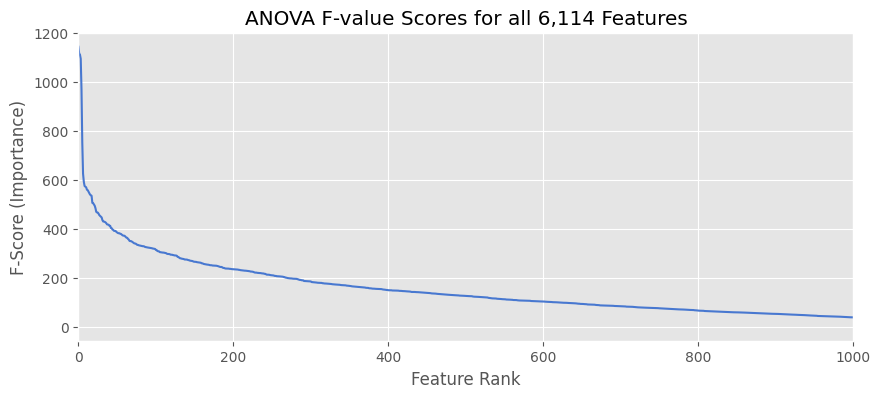

Selecting the top 300 most important features...
Original Training features: 1182
Reduced Training features:  300


In [ ]:
# --- Step 11 (REVISED): Phase 4 - Scaling & Supervised Feature Selection ---
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
import matplotlib.pyplot as plt

print("Scaling features...")
# 1. Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Applying ANOVA F-value Feature Selection...")
# 2. Score all features against the labels (y_train)
selector_test = SelectKBest(score_func=f_classif, k='all')
selector_test.fit(X_train_scaled, y_train)

# Plot the feature scores to see how many are actually useful
scores = np.sort(selector_test.scores_)[::-1] # Sort descending
plt.figure(figsize=(10, 4))
plt.plot(scores)
plt.title('ANOVA F-value Scores for all 6,114 Features')
plt.xlabel('Feature Rank')
plt.ylabel('F-Score (Importance)')
plt.xlim(0, 1000) # Zoom in on the top 1000
plt.grid(True)
plt.show()

# 3. Select the Top 300 best features
K_BEST = 300
print(f"Selecting the top {K_BEST} most important features...")

selector_final = SelectKBest(score_func=f_classif, k=K_BEST)
X_train_selected = selector_final.fit_transform(X_train_scaled, y_train)
X_test_selected = selector_final.transform(X_test_scaled)

print(f"Original Training features: {X_train_scaled.shape[1]}")
print(f"Reduced Training features:  {X_train_selected.shape[1]}")

In [ ]:
# --- Step 12: Phase 5 - Train SVM (with Grid Search) ---
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
import time

print("Training Support Vector Machine (SVM)...")
print("This may take a few minutes depending on your CPU.")
start_time = time.time()

# A focused grid to save time.
# (C controls penalty for misclassification, gamma controls the 'spread' of the kernel)
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto']
}

# Initialize base SVM
svm_base = SVC(kernel='rbf', class_weight='balanced', random_state=42)

# Set up Grid Search (cv=3 means 3-fold cross-validation)
svm_grid = GridSearchCV(svm_base, param_grid, cv=3, n_jobs=-1, verbose=2)

# Fit the model
svm_grid.fit(X_train_selected, y_train)

# Extract the best model
svm_best = svm_grid.best_estimator_

elapsed_time = (time.time() - start_time) / 60
print(f"\n SVM Training completed in {elapsed_time:.2f} minutes.")
print(f"Best SVM Parameters: {svm_grid.best_params_}")

# Quick accuracy check (We will do deep evaluation in Phase 6)
print(f"SVM Train Accuracy: {svm_best.score(X_train_selected, y_train):.4f}")
print(f"SVM Test Accuracy:  {svm_best.score(X_test_selected, y_test):.4f}")

Training Support Vector Machine (SVM)...
This may take a few minutes depending on your CPU.
Fitting 3 folds for each of 6 candidates, totalling 18 fits

 SVM Training completed in 3.50 minutes.
Best SVM Parameters: {'C': 10, 'gamma': 'auto'}
SVM Train Accuracy: 0.9451
SVM Test Accuracy:  0.7100


In [ ]:
# --- Step 13: Phase 5 - Train Random Forest ---
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest...")
start_time = time.time()

# Initialize Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1 # Use all available CPU cores
)

# Fit the model
rf_model.fit(X_train_selected, y_train)

elapsed_time = (time.time() - start_time) / 60
print(f"\n Random Forest Training completed in {elapsed_time:.2f} minutes.")

# Quick accuracy check
print(f"RF Train Accuracy: {rf_model.score(X_train_selected, y_train):.4f}")
print(f"RF Test Accuracy:  {rf_model.score(X_test_selected, y_test):.4f}")

Training Random Forest...

 Random Forest Training completed in 0.72 minutes.
RF Train Accuracy: 0.9873
RF Test Accuracy:  0.6837


In [ ]:
# --- Step 14: Phase 5 - Train XGBoost (Anti-Overfitting Setup) ---
import time
from sklearn.utils.class_weight import compute_sample_weight

# Try importing xgboost, install if missing
try:
    import xgboost as xgb
except ImportError:
    import subprocess, sys
    print("Installing XGBoost...")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'xgboost'])
    import xgboost as xgb

print("Training XGBoost with Regularization (Anti-Overfitting)...")
start_time = time.time()

# 1. Calculate sample weights to handle class imbalance
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# 2. Initialize XGBoost with parameters designed to PREVENT overfitting
xgb_model = xgb.XGBClassifier(
    n_estimators=300,         # Number of trees
    max_depth=4,              # Shallow trees (default is 6)
    learning_rate=0.05,       # Slow learning
    subsample=0.8,            # Use 80% of data per tree
    colsample_bytree=0.8,     # Use 80% of features per tree
    reg_lambda=5.0,           # Strong L2 Regularization (default is 1)
    reg_alpha=1.0,            # L1 Regularization
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1                 # Use all CPU cores
)

# 3. Fit the model
xgb_model.fit(
    X_train_selected,
    y_train,
    sample_weight=sample_weights
)

elapsed_time = (time.time() - start_time) / 60
print(f"\n XGBoost Training completed in {elapsed_time:.2f} minutes.")

# 4. Accuracy check
print(f"XGB Train Accuracy: {xgb_model.score(X_train_selected, y_train):.4f}")
print(f"XGB Test Accuracy:  {xgb_model.score(X_test_selected, y_test):.4f}")

Training XGBoost with Regularization (Anti-Overfitting)...

 XGBoost Training completed in 1.23 minutes.
XGB Train Accuracy: 0.8732
XGB Test Accuracy:  0.7072


In [ ]:
# --- Step 15: Phase 5 - Train Logistic Regression (Highly Resistant to Overfitting) ---
from sklearn.linear_model import LogisticRegression

print("Training Logistic Regression...")
start_time = time.time()

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    C=0.1, # Strong L2 Regularization
    random_state=42,
    n_jobs=-1
)

log_reg.fit(X_train_selected, y_train)

elapsed_time = (time.time() - start_time) / 60
print(f"\n✅ Logistic Regression Training completed in {elapsed_time:.2f} minutes.")
print(f"LogReg Train Accuracy: {log_reg.score(X_train_selected, y_train):.4f}")
print(f"LogReg Test Accuracy:  {log_reg.score(X_test_selected, y_test):.4f}")

Training Logistic Regression...

✅ Logistic Regression Training completed in 0.04 minutes.
LogReg Train Accuracy: 0.7251
LogReg Test Accuracy:  0.6574


In [ ]:
# --- Step 16: Phase 5 - Train XGBoost (Extreme Regularization) ---
print("Training XGBoost with Extreme Regularization...")
start_time = time.time()

# 1. Calculate sample weights for the imbalanced classes
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# 2. Initialize tightly constrained XGBoost
xgb_extreme = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=3,              # Decreased from 4 to 3 (Very shallow)
    learning_rate=0.03,       # Slower learning
    subsample=0.7,            # More aggressive data dropout
    colsample_bytree=0.7,     # More aggressive feature dropout
    min_child_weight=5,       # NEW: Stops trees from splitting for noisy outliers
    gamma=1.0,                # NEW: Requires a strict loss reduction to split
    reg_lambda=10.0,          # Heavy L2 penalty
    reg_alpha=2.0,            # Heavy L1 penalty
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

xgb_extreme.fit(X_train_selected, y_train, sample_weight=sample_weights)

elapsed_time = (time.time() - start_time) / 60
print(f"\n Extreme XGB Training completed in {elapsed_time:.2f} minutes.")
print(f"Extreme XGB Train Accuracy: {xgb_extreme.score(X_train_selected, y_train):.4f}")
print(f"Extreme XGB Test Accuracy:  {xgb_extreme.score(X_test_selected, y_test):.4f}")

Training XGBoost with Extreme Regularization...

 Extreme XGB Training completed in 1.10 minutes.
Extreme XGB Train Accuracy: 0.7607
Extreme XGB Test Accuracy:  0.6804


In [ ]:
# --- Step 17: Phase 5 - Train Soft Voting Ensemble ---
from sklearn.ensemble import VotingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

print("Initializing Voting Ensemble (XGBoost + SVM + Logistic Regression)...")
start_time = time.time()

# 1. Define base models
# (Using probability=True for SVM so it can participate in Soft Voting)
clf_svm = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)
clf_log = LogisticRegression(max_iter=1000, C=0.05, random_state=42)
clf_xgb = xgb_extreme # We reuse the heavily constrained model from above

# 2. Build the Ensemble
# We give XGBoost a weight of 2, since it is historically your strongest model
ensemble = VotingClassifier(
    estimators=[
        ('xgb', clf_xgb),
        ('svm', clf_svm),
        ('log', clf_log)
    ],
    voting='soft',
    weights=[2, 1, 1]
)

# 3. Fit the Ensemble (Passing sample_weights to handle class imbalance)
ensemble.fit(X_train_selected, y_train, sample_weight=sample_weights)

elapsed_time = (time.time() - start_time) / 60
print(f"\n Ensemble Training completed in {elapsed_time:.2f} minutes.")
print(f"Ensemble Train Accuracy: {ensemble.score(X_train_selected, y_train):.4f}")
print(f"Ensemble Test Accuracy:  {ensemble.score(X_test_selected, y_test):.4f}")

Initializing Voting Ensemble (XGBoost + SVM + Logistic Regression)...

 Ensemble Training completed in 2.08 minutes.
Ensemble Train Accuracy: 0.8509
Ensemble Test Accuracy:  0.7120


Generating predictions with the Voting Ensemble...

 FINAL ENSEMBLE CLASSIFICATION REPORT
                              precision    recall  f1-score   support

                     A (AMD)       0.93      0.89      0.91       102
                C (Cataract)       0.98      0.98      0.98       202
    D (Diabetic Retinopathy)       0.76      0.49      0.60       626
                G (Glaucoma)       0.73      0.67      0.70       329
H (Hypertensive Retinopathy)       0.76      0.70      0.73        84
                  M (Myopia)       0.55      0.63      0.59       148
                  N (Normal)       0.62      0.86      0.72       599

                    accuracy                           0.71      2090
                   macro avg       0.76      0.75      0.75      2090
                weighted avg       0.73      0.71      0.71      2090

Plotting Confusion Matrix...


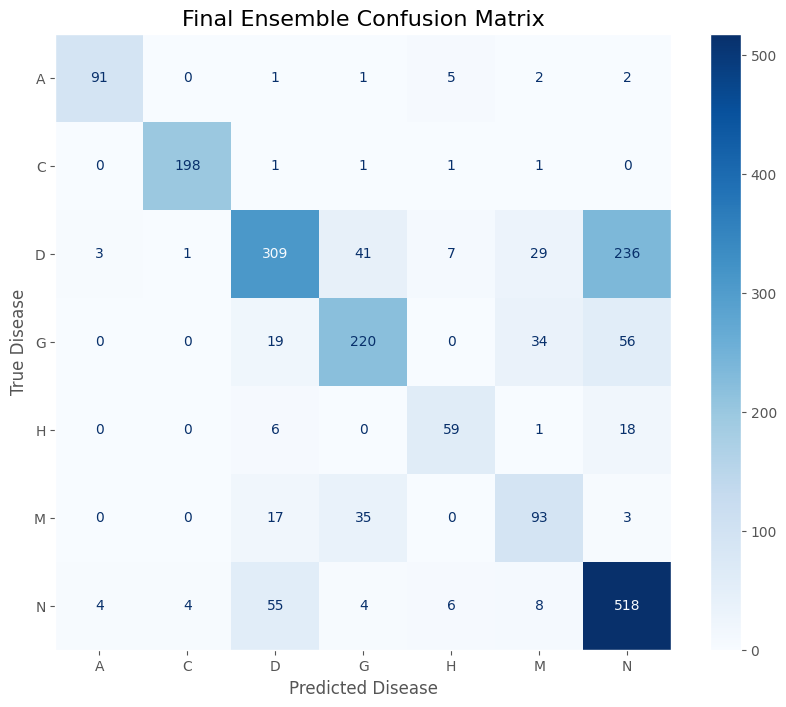


Project Pipeline Complete!


In [ ]:
# --- Step 18: Phase 6 - Final Evaluation (Confusion Matrix & Classification Report) ---
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Generating predictions with the Voting Ensemble...")
# Predict on the test set
y_pred = ensemble.predict(X_test_selected)

# 1. Classification Report (Precision, Recall, F1-Score per class)
# Map encoded integers back to their original string labels ('A', 'C', etc.)
target_names = [f"{cls} ({FULL_NAMES.get(cls, cls)})" for cls in le.classes_]

print("\n" + "="*60)
print(" FINAL ENSEMBLE CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=target_names))

# 2. Confusion Matrix
print("Plotting Confusion Matrix...")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
# We use le.classes_ to show the letter codes (A, C, D...) on the axes
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues, ax=plt.gca(), values_format='d')

plt.title('Final Ensemble Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Disease', fontsize=12)
plt.ylabel('True Disease', fontsize=12)
plt.grid(False) # Turn off grid lines for a cleaner matrix view
plt.show()

print("\nProject Pipeline Complete!")